# The Tampa Bay Rays 2020 Pitching Staff: A Masterclass in Market Efficiency

The Tampa Bay Rays finished the shortened 2020 season with the third lowest ERA in the league, behind only the Dodgers and the Indians. The interesting part, is that the Rays were in the bottom 5 of spenders. That year the Rays spent almost $29 million on their entire roster, less than half of league average. The scatterplot below shows team average payroll vs wins from 2011-2024, with the Rays being the farthest point on the left, wildly outperforming their expected wins total (based off of payroll). In a league with no salary cap and huge market competition, a feat such as this is unheard of. Here we will dive into the front office moves and strategies utilized by Tampa Bay to build one of the best pitching staffs in the league, one that propelled them to the World Series, on the tightest budget in the league. I present to you: A Masterclass in Market Efficiency

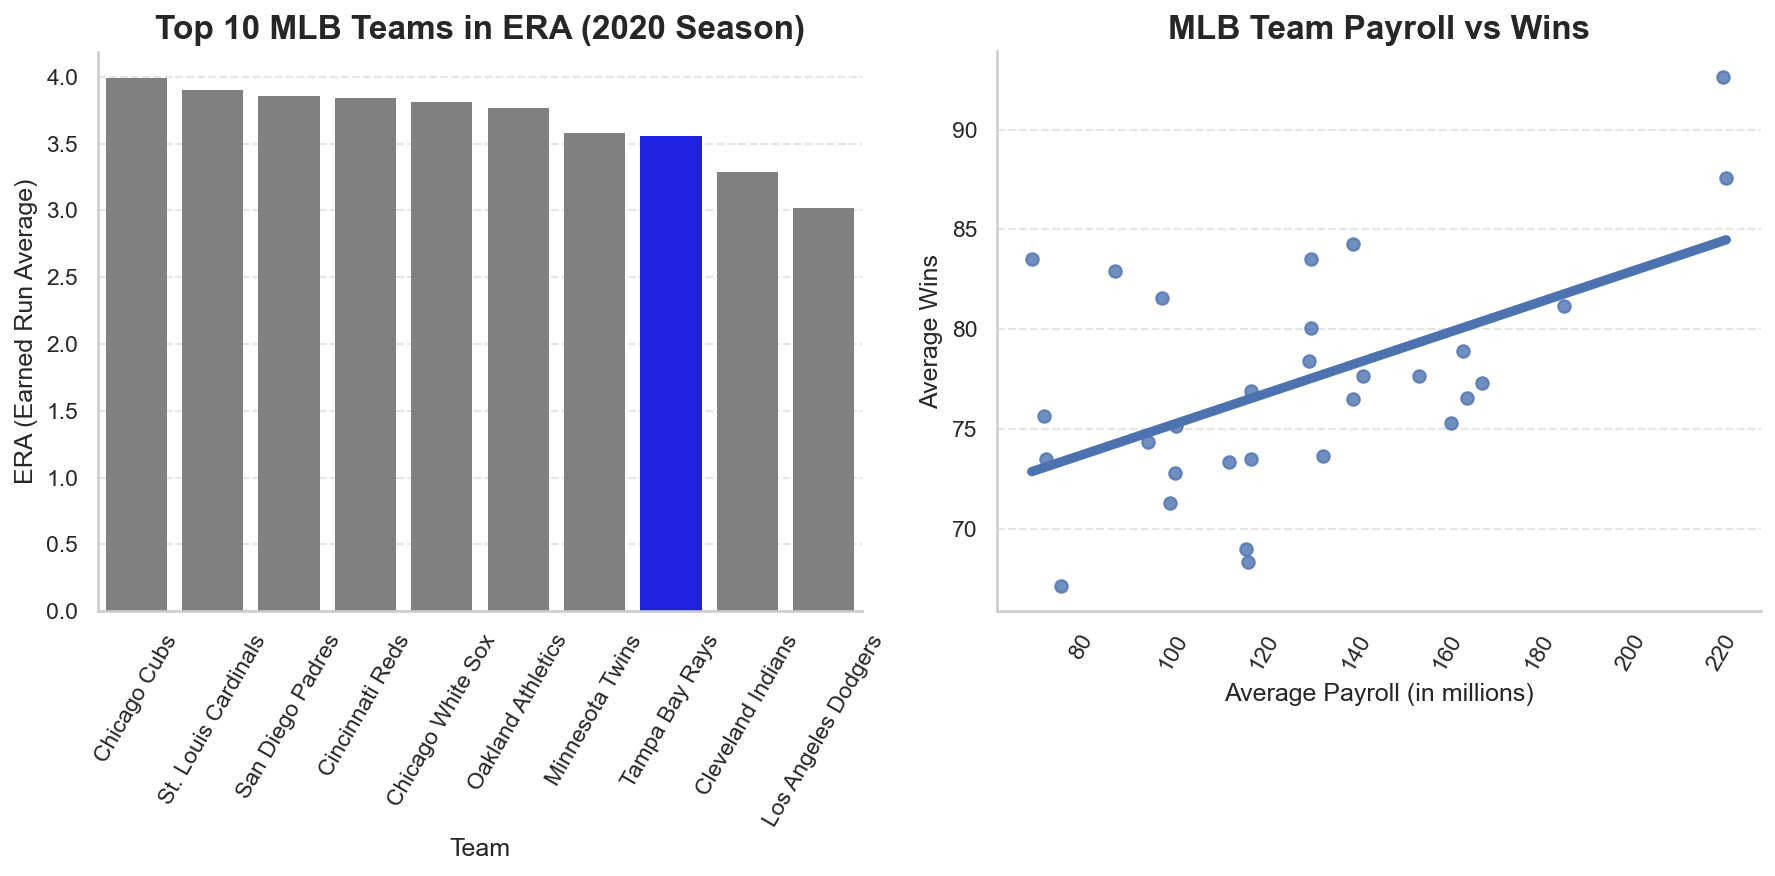

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "sans-serif",
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        
        "figure.dpi": 150,
        
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,  
        "axes.grid.axis": "y",  
        "grid.linestyle": "--",
        "grid.color": "#E5E5E5",
        
        "lines.linewidth": 3,
        "patch.linewidth": 0,
    },
)

team_2020_pitchstats = pd.read_csv("team_2020_pitchstats.csv", index_col="Tm").sort_values("ERA", ascending=True).head(10)

total_team_2020_stats = team_2020_pitchstats.copy()
total_team_2020_stats["Rays"] = total_team_2020_stats.apply(lambda x: True if x.name == "Tampa Bay Rays" else False, axis=1)
team_ERA_sorted = total_team_2020_stats.sort_values(by="ERA", ascending=False)

mlb_data = pd.read_csv("mlb_payrolls.csv", index_col="Team Name")
mlb_data["Total Payroll Allocations"] = mlb_data["Total Payroll Allocations"].str.replace(r'[\$,]', '', regex=True).astype(float) / 1_000_000  # Convert to millions
grouped_mlb_data = mlb_data.groupby("Team Name").agg({"Total Payroll Allocations": "mean", "Wins": "mean"}).reset_index()

grouped_mlb_data = grouped_mlb_data.rename(columns={"Total Payroll Allocations": "Average Payroll (in millions)", "Wins": "Average Wins"})

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=team_ERA_sorted, x="Tm", y="ERA", hue="Rays", palette={True: "blue", False: "gray"}, legend=False)
plt.xlabel('Team')
plt.ylabel('ERA (Earned Run Average)')
plt.title('Top 10 MLB Teams in ERA (2020 Season)')
plt.xticks(rotation=60)


plt.subplot(1, 2, 2)
sns.regplot(data=grouped_mlb_data, x='Average Payroll (in millions)', y='Average Wins', ci=None)
plt.xlabel('Average Payroll (in millions)')
plt.ylabel('Average Wins')
plt.title('MLB Team Payroll vs Wins')


plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## The Rotation

The Rays built a very strong, roughly 6 man rotation over the course of the 2020 season. Going into the season, Yonny Chirinos was supposed to be a major starter in the rotation, but after going down and having to get Tommy John surgery in late August, Josh Fleming and Trevor Richards filled in, both pitching over 30 innings for the squad. Costing the team around $25.8 million (adjusted to $9.4 million for 2020 salaries), these 6 pitchers alone made up more than a 1/3 of the Ray's tiny payroll for the year. 

In [13]:
rays_2020 = pd.read_csv("rays_2020_salary.csv").set_index("player")
rays_2020_pitchstats = pd.read_csv("rays_2020_pitchstats.csv").set_index("player")
rays_2020_pitchstats["W-L%"] = rays_2020_pitchstats["W-L%"].fillna(0)  
rays_2020["2020 Adjusted Salary (millions)"] = round(rays_2020["salary (millions)"] * 0.37, 3)

rays_2020_pitchers = rays_2020[rays_2020["pos"] == "p"]

rays_2020_pitchers = rays_2020_pitchers.merge(rays_2020_pitchstats, left_index=True, right_index=True)
rays_2020_pitchers["SP"] = rays_2020_pitchers["GS"].apply(lambda x: True if x > 0 else False)

print(rays_2020_pitchers[rays_2020_pitchers["SP"] == True][["IP", "ERA", "ERA+", "GS", "2020 Adjusted Salary (millions)"]].reset_index().sort_values("GS", ascending=False).head(6))

             player    IP   ERA   ERA+  GS  2020 Adjusted Salary (millions)
4     Tyler Glasnow  57.1  4.08  100.0  11                            0.758
9       Blake Snell  50.0  3.24  127.0  11                            2.590
6    Charlie Morton  38.0  4.74   87.0   9                            5.550
11   Ryan Yarbrough  55.2  3.56  115.0   9                            0.214
3      Josh Fleming  32.1  2.78  148.0   5                            0.208
7   Trevor Richards  32.0  5.91   70.0   4                            0.213


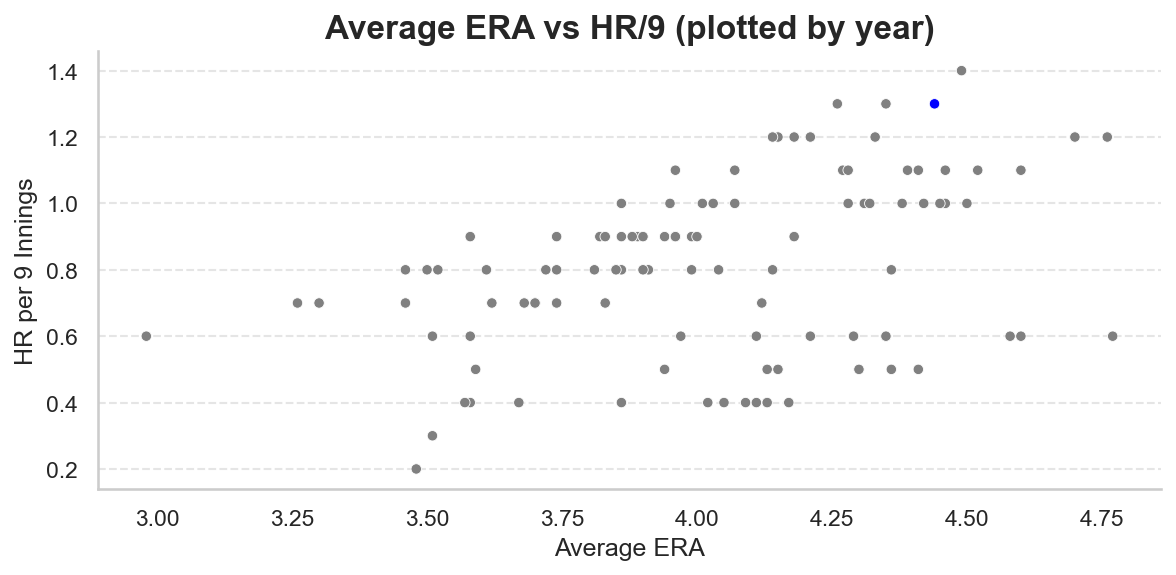

In [14]:
pitching_avg_by_year = pd.read_csv("pitching_avg_by_year.csv")
pitching_avg_by_year["2020"] = pitching_avg_by_year.apply(lambda x: True if x.Year == 2020 else False, axis=1)

plt.figure(figsize=(8, 4))
sns.scatterplot(data=pitching_avg_by_year, x="ERA", y="HR9", hue="2020", palette={True: "Blue", False: "Grey"}, legend=False, s=25)
plt.xlabel("Average ERA")
plt.ylabel("HR per 9 Innings")
plt.title("Average ERA vs HR/9 (plotted by year)")
plt.tight_layout()
plt.show()

Blake Snell, Tyler Glasnow, and Ryan Yarbough became a three-headed monster for this rotation. Pitching in over 160 innings between the 3 of them and posting an average ERA+ of 114 between the 3 of them, and an average of a 3.63 ERA. This ERA was almost a point lower than the average ERA for the year, 4.44, which is the 15th highest average ERA for the league since the live ball era. Pitching strength and dominance during the year was more important than ever and played a vital role in the success of this Rays team. The chart below shows the average ERA and home runs per 9 innings. Highlighted in blue is 2020, a year in which both these stats were especially high leading to this year and 2019 being coined as the "juiced ball era." The acquisition of these 3 pitchers who helped the Rays survive the juiced ball era all came from strokes of genius from the entire organization. This came through not only high level scouting but also trade negotiation.

### The Chris Archer Trade

The acquisition of Tyler Glasnow in 2018 as an absolute stroke of genius by the Rays front office. With Chris Archer coming off an all star season the year prior while also finishing in the top 3 in strikeouts, he was a top target for lots of teams. His contract (for the Rays standards) was quite large, costing them over $6 million that year and reaching around $7 million in the year after. This move with the Pirates sent a struggling 6'8 Tyler Glasnow to Tampa Bay, alongside Austin Meadows (future all-star) as well as top prospect Shane Baz.

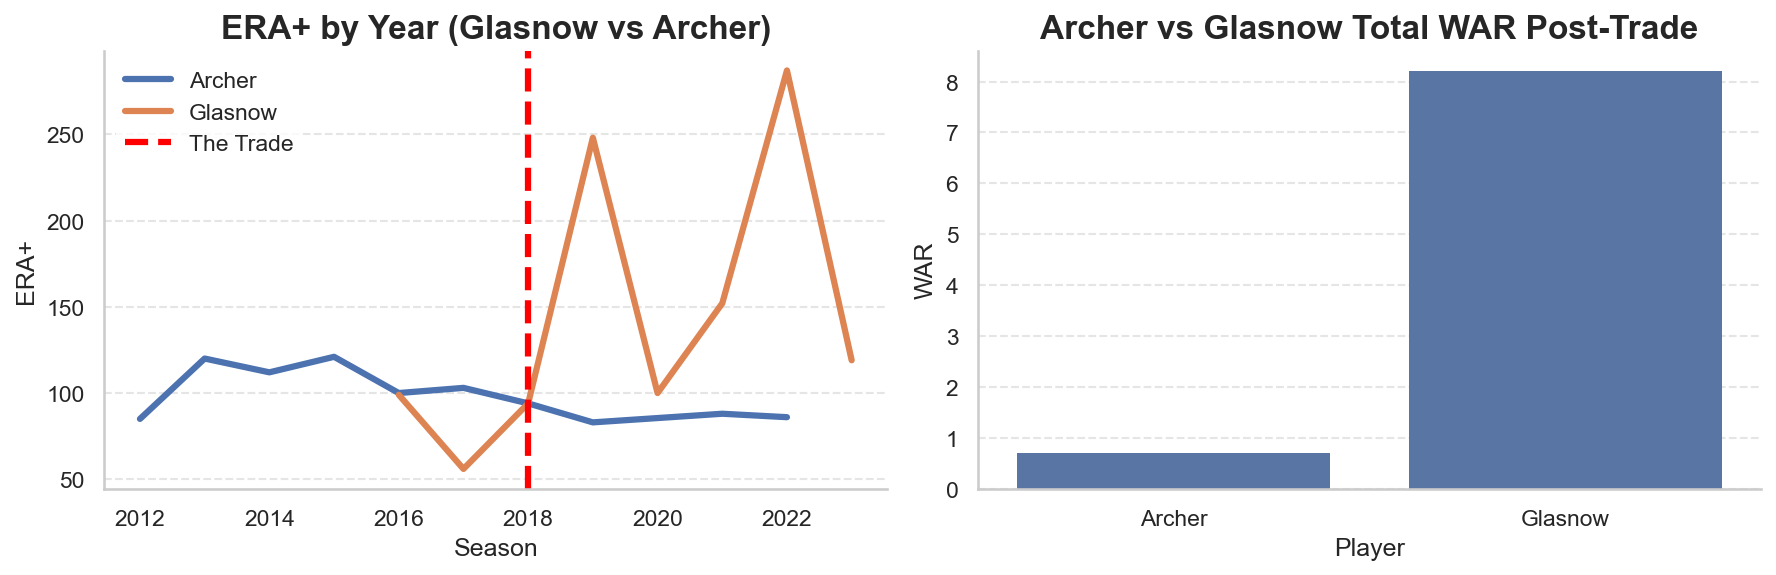

In [15]:
glasnow_trade = pd.read_csv("glasnow_trade.csv", index_col="Player")
comparison_trade = glasnow_trade[glasnow_trade["Season"] >= 2019]
comparison_barplot = comparison_trade.groupby("Player")["WAR"].sum().reset_index()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=glasnow_trade, x="Season", y="ERA+", hue="Player")
plt.xlabel("Season")
plt.ylabel("ERA+")
plt.title("ERA+ by Year (Glasnow vs Archer)")
plt.axvline(x=2018, linestyle="--", color="red", label="The Trade")
plt.legend()

plt.subplot(1, 2, 2)
sns.barplot(data=comparison_barplot, x="Player", y="WAR")
plt.xlabel("Player")
plt.ylabel("WAR")
plt.title("Archer vs Glasnow Total WAR Post-Trade")
plt.tight_layout()
plt.savefig("glasnowtradepng", dpi=150, bbox_inches='tight')
plt.show()

As pictured above, Glasnow was floating below league average in ERA+ while Archer stayed at above average from 2012 to 2018. Heading into his age 29 season, it looked like this dominance would continue from Archer. After posting the exact same ERA+ in 2018, the newly acquired Glasnow posted outstanding above-average ERA+ numbers while Archer's career took a bad turn. In the years following, Glasnow's breakout resulted in a total 8.7 WAR during his stint at the Rays, while in the rest of Archer's career he didn't even crack 1. In addition to these great numbers from Glasnow, his cost played a significant role in building the squad that the Rays did. Refering to the chart at the beginning of the section, Glasnow's salary was less than $1 million during 2020 and almost $2 million cheaper than an old Archer would've costed them. FanGraphs stated that the average cost for 1 Win Above Replacement in 2020 was $4-6 million for the entire league. Glasnow's production based off of WAR was worth around $40 million for his time in Tampa Bay, and they only paid him around $16 million during his entire time at the ballclub. This investment in young talent and capitalization on pre-free agency contracts is a reoccuring theme for the Rays, and one we will touch on in later sections of this project. As a result of this trade, they not only cut spending but increased output by a margin that would've cost them 10s of millions of dollars to do otherwise.

### Snellzilla

Blake Snell's rise to becoming the 2018 CY Young Winner, and the 2020 Rays ace was a product of great scouting and player development by the Rays organization. Snell was selected 52nd overall by the Rays out of Shorewood High School. Committed to the University of Washington at the time, Snell opted to go to the MLB and begin his career in the Rays system. He was actually the 2nd pitcher selected by the Rays in the draft that year, and scouts weren't very high on him. His fastball only topped 92 and his inconsistent control, especially with his breaking stuff, was a real deterrent for most scouts. Tampa Bay's farm system and player development staff played a large role in turning Blake Snell into the CY Young winner he is today. His development in the minors saw major development in his stuff. His strong fastball improved, while major focus on his offspeed led to him improving his changeup, slider, and adding in a curveball in 2016 (rated 55 on the scale.) Improving his arsenal combined with filling out his lanky 6'4 frame made him an absolute monster once he made his major league debut in 2016 as the Rays' #1 prospect. After all this development in the organization, Snell was the ace for the Rays during the 2020 year, posting a 127 ERA+.

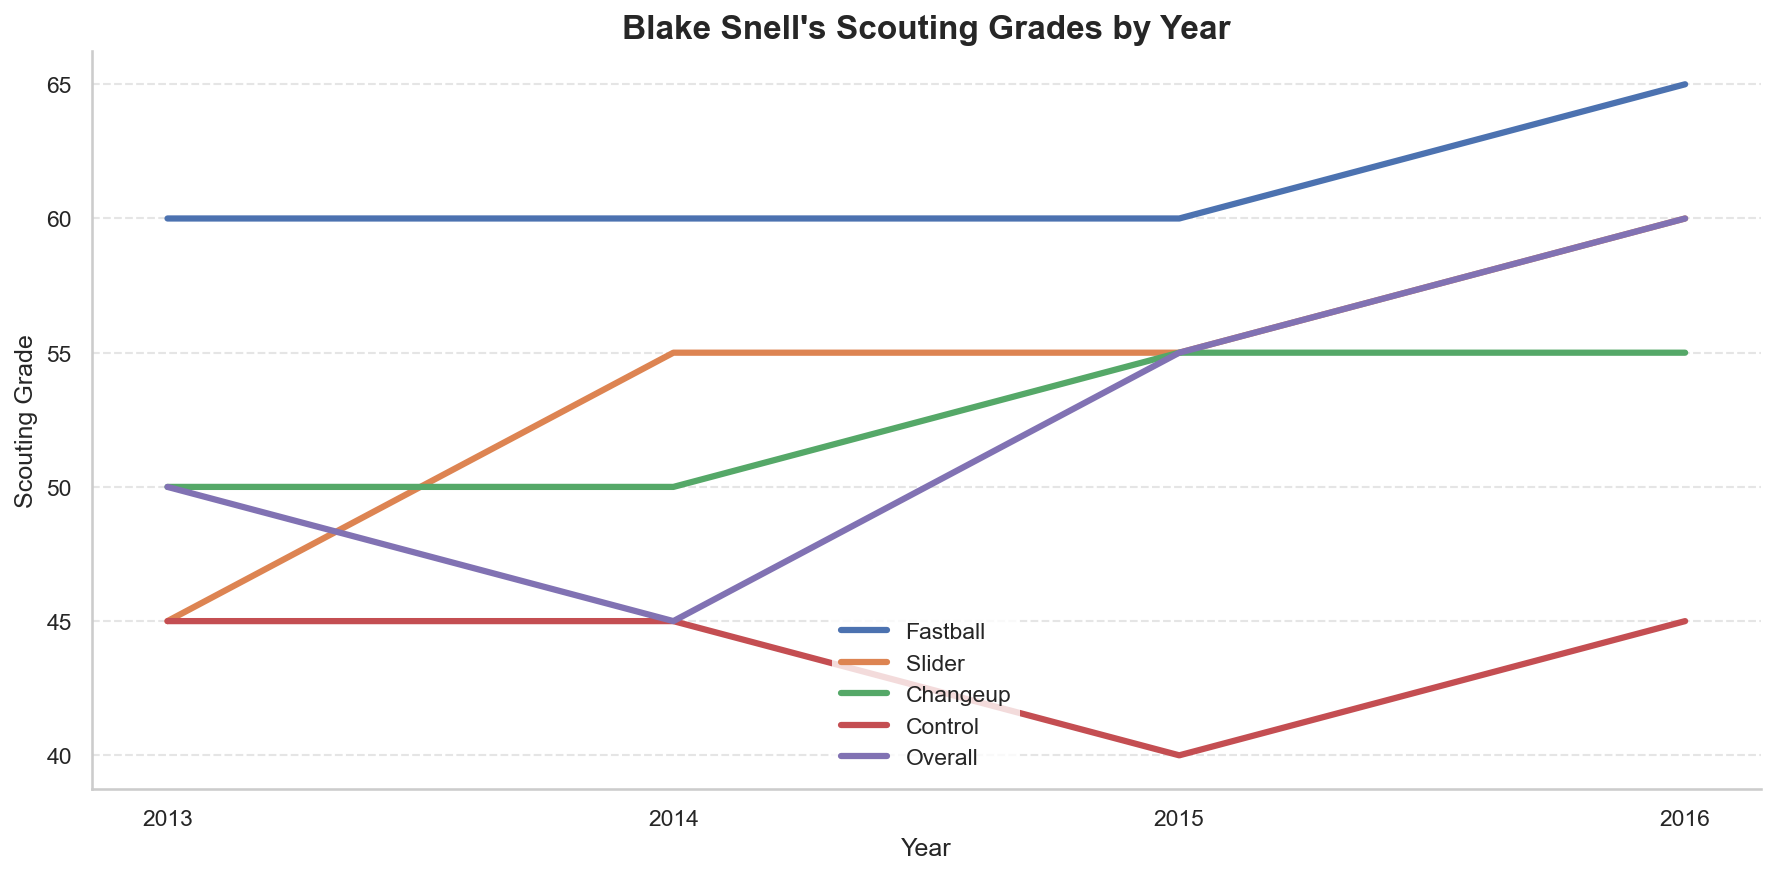

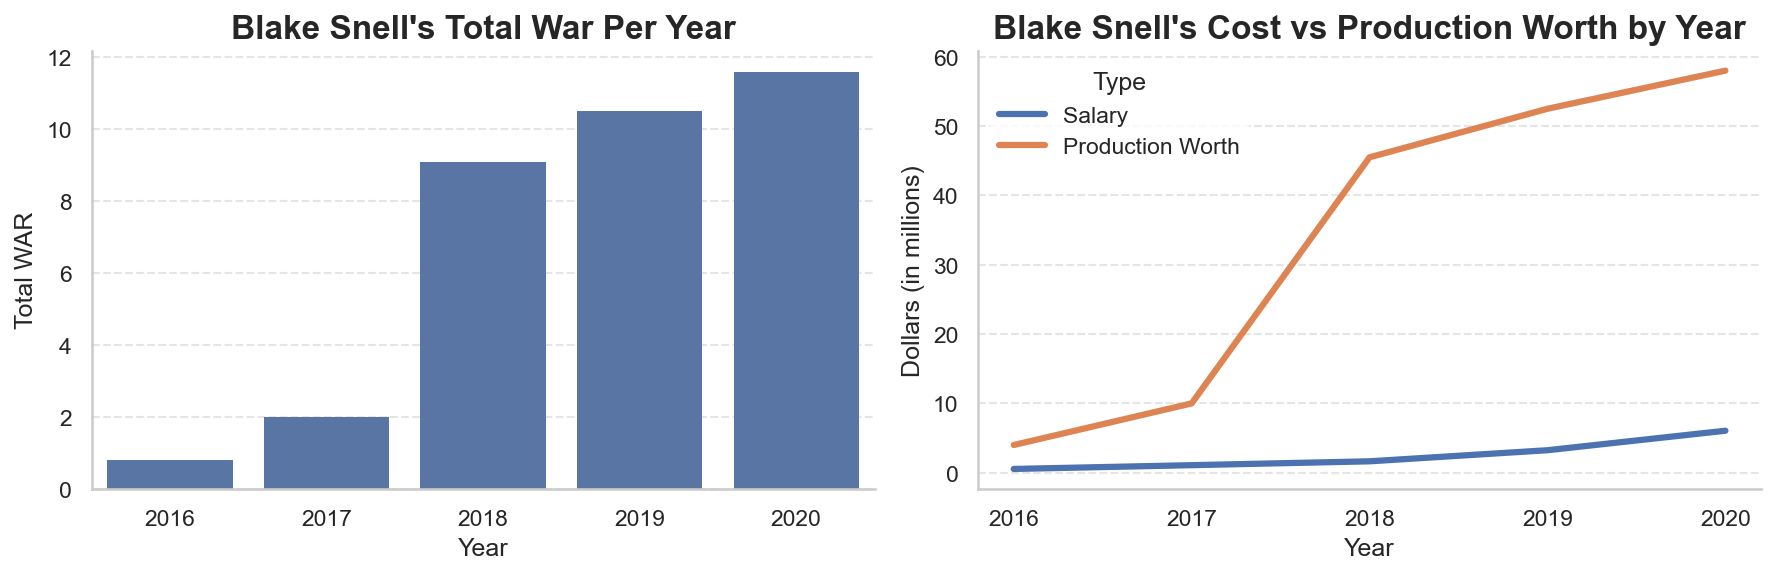

In [16]:
snell_scouting = pd.read_csv("snell_scouting.csv", index_col="Year")
snell_salary = pd.read_csv("snell_salary.csv", index_col="Year")

plt.figure(figsize=(12,6))
y = sns.lineplot(data=snell_scouting, x="Year", y="Grade", hue="Category")
y.xaxis.set_major_locator(MultipleLocator(1))
plt.xlabel("Year")
plt.ylabel("Scouting Grade")
plt.title("Blake Snell's Scouting Grades by Year")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
sns.barplot(data=snell_salary, x="Year", y="Total WAR")
plt.xlabel("Year")
plt.ylabel("Total WAR")
plt.title("Blake Snell's Total War Per Year")

plt.subplot(1, 2, 2)
y = sns.lineplot(data=snell_salary, x="Year", y="Cost", hue="Type")
y.xaxis.set_major_locator(MultipleLocator(1))
plt.xlabel("Year")
plt.ylabel("Dollars (in millions)")
plt.title("Blake Snell's Cost vs Production Worth by Year")
plt.tight_layout()
plt.savefig("snellzillapng", dpi=150, bbox_inches='tight')
plt.show()

They got him at quite a deal as well, with Snell's original $7 million dollar salary (before COVID season adjustments) being ranked at 57th for starting pitchers that year. This development paid off significantly for the Rays organization because of his output during the 5 years leading up to and including the 2020 season. Utilizing the same FanGraphs cost per WAR number from earlier, this means that Blake Snell's pitching dominance saved the Rays around $50 million dollars in what would've costed them if they searched the market somewhere else to match his output. Between the seasons of 2016 and 2020, Snell racked up an 11.6 career war. Equating that to the cost of 1 war, Snell's output is worth between $55-60 million dollars. Capitalizing on pre-free agency the Rays only paid him a little over $6 million, around a 1/10 of what his production would've earned him in free agency. This is another insane investment by the Rays front office to get the most bang for their buck. 

### The Sidewinder

Pictured below is a scatterplot which shows the average shoulder distance and release point angle of all qualified lefties during the 2020 season. The farther you go to the right, the greater the distance is from a pitcher's shoulder to the center of mass at release point. The higher up you are on the chart, the greater the angle of release. Bottom right would signify a true sidewinder, a pitcher who throws sidearm, perpendicular from the body. The blue dot in that region is the third of the big 3 contributors in the Rays' starting rotation, a truly uncanny pitcher named Ryan Yarbrough.

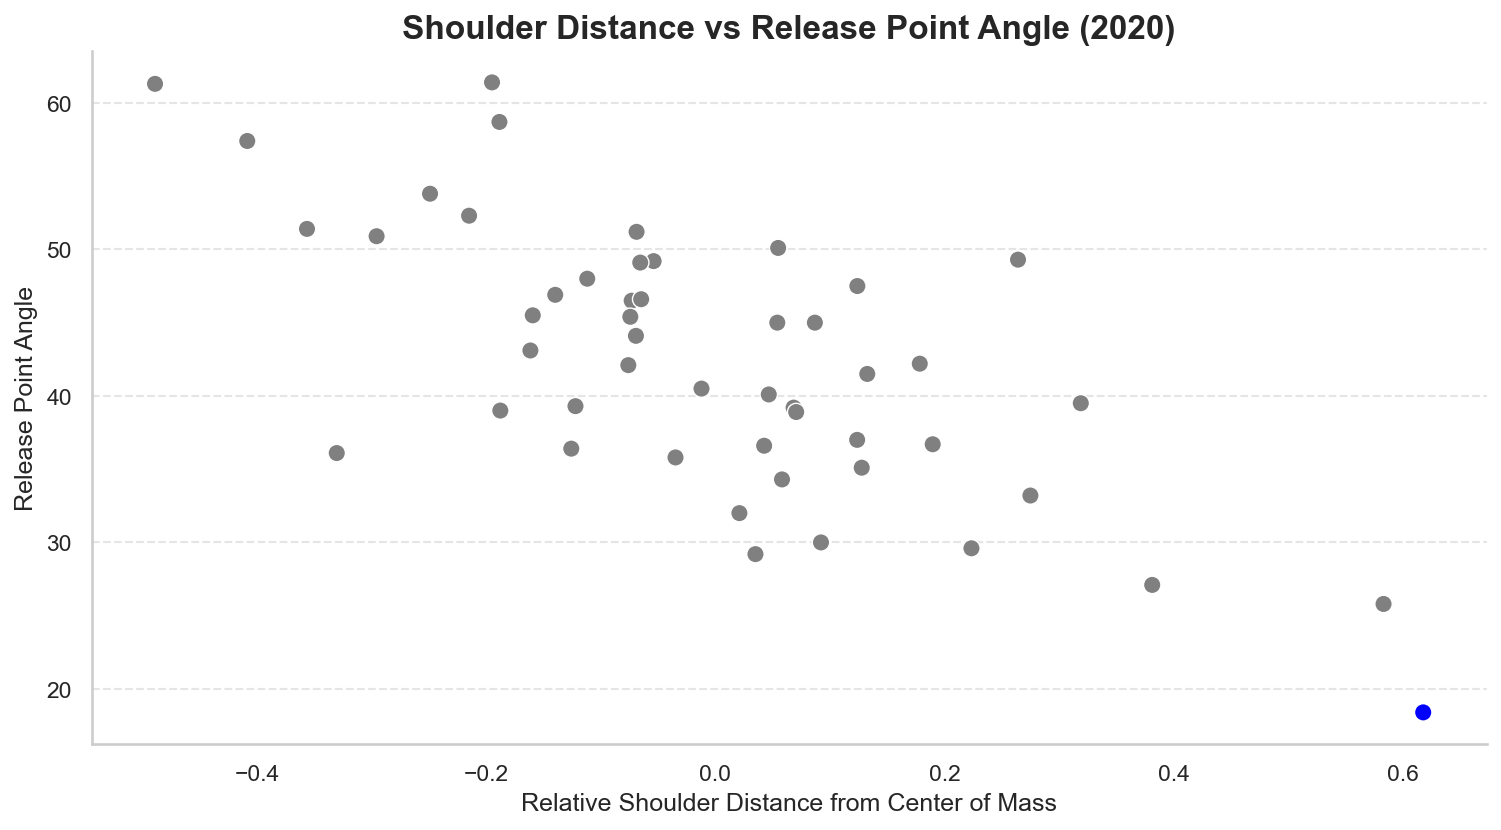

In [17]:
pitcher_arm_angles = pd.read_csv("pitcher_arm_angles.csv")
lefty_arm_angles = pitcher_arm_angles[pitcher_arm_angles["pitch_hand"] == "L"]
lefty_arm_angles["Yarbrough"] = lefty_arm_angles.apply(lambda x: True if x.pitcher_name == "Yarbrough, Ryan" else False, axis=1)

plt.figure(figsize=(12,6))
sns.scatterplot(data=lefty_arm_angles, x="relative_shoulder_x", y="ball_angle", hue="Yarbrough", palette={True: "Blue", False: "Grey"}, legend=False, s=70)
plt.xlabel("Relative Shoulder Distance from Center of Mass")
plt.ylabel("Release Point Angle")
plt.title("Shoulder Distance vs Release Point Angle (2020)")
plt.show()

The 6'5 lefty from Austin, Texas is easily the most interesting out of the 3 pitchers that were a part of Tampa Bay's "big 3." Drafted in the 4th round by the Mariners, Yarbrough was a part of a deal between the Mariners and Rays in 2017. This deal saw the Rays send reliever Drew Smyly to Seattle in exchange for prospects Mallex Smith, Carlos Vargas, and Ryan Yarbrough. Yarbrough was a very unorthodox pitcher, throwing from such a weird arm angle and primarily throwing cutters and changeups. In 2020, Yarbrough threw these 2 pitches alone around 2/3 of the time, and was unbelievably successful with them. He posted a 115 ERA+, but more importantly he was in the 99th percentile in avg exit velo, and 98th percentile for chase and hard hit percentage. These rankings were all very important considering the juiced ball 2019-2020 era which saw teams hitting tons of homers and having loads of hard contact. Looking back on this deal, it paid off huge for the Rays in not only on field production but budgetary reasons as well. 

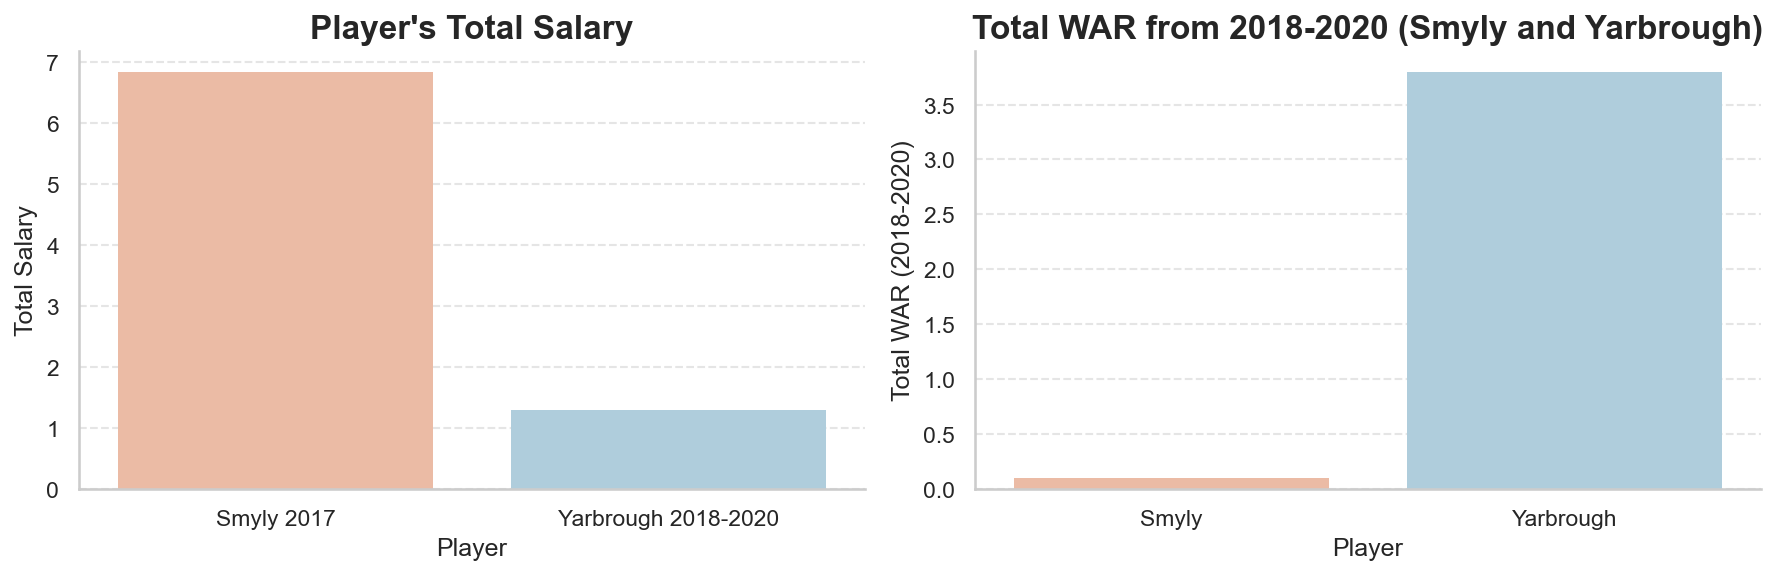

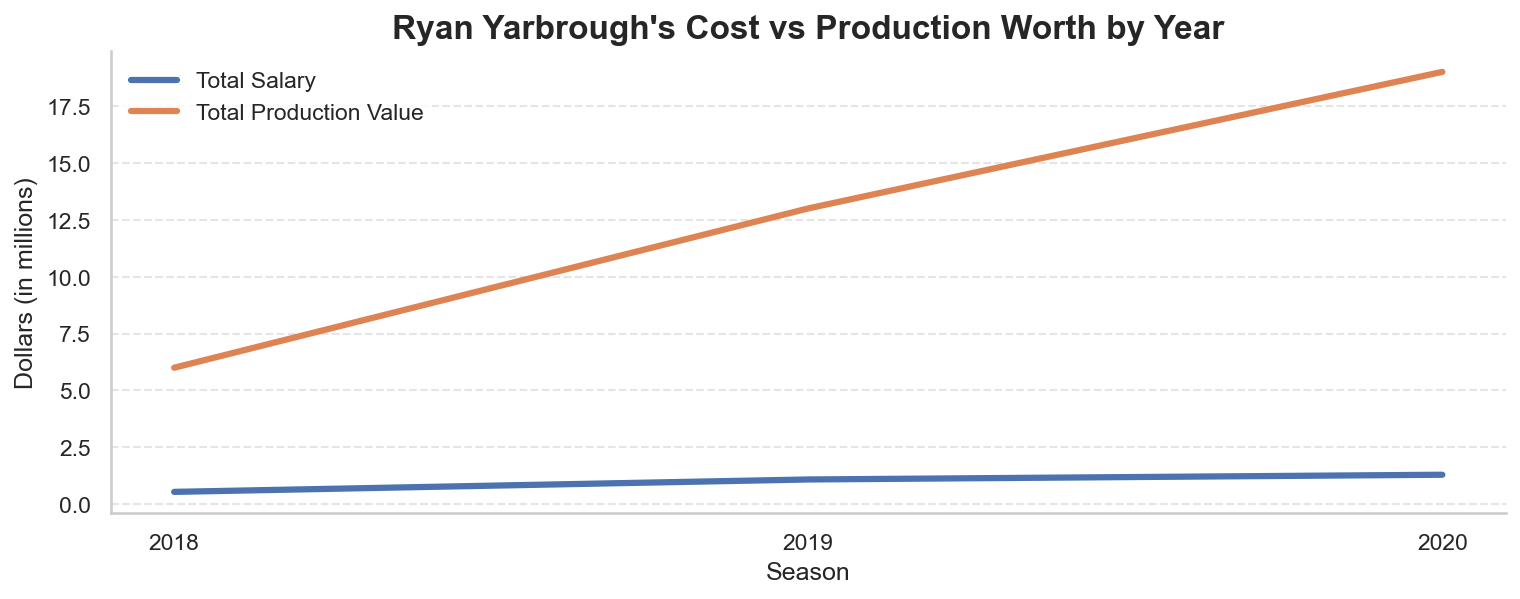

In [18]:
yarbrough_stats = pd.read_csv("yarbrough_stats.csv")
yarbrough_salary = pd.read_csv("yarbrough_salary.csv", index_col="Player")
yarbrough_lineplot = pd.read_csv("yarbrough_lineplot.csv")
yarbrough_war = yarbrough_stats.groupby("Player")["WAR"].sum().reset_index()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.barplot(data=yarbrough_salary, x="Player", y="Salary (millions)", hue="Player", palette= "RdBu")
plt.xlabel("Player")
plt.ylabel("Total Salary")
plt.title("Player's Total Salary")

plt.subplot(1,2,2)
sns.barplot(data=yarbrough_war, x="Player", y="WAR", hue="Player", palette="RdBu")
plt.xlabel("Player")
plt.ylabel("Total WAR (2018-2020)")
plt.title("Total WAR from 2018-2020 (Smyly and Yarbrough)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
y = sns.lineplot(data=yarbrough_lineplot, x="Season", y="Cost",hue="Type")
y.xaxis.set_major_locator(MultipleLocator(1))
plt.xlabel("Season")
plt.ylabel("Dollars (in millions)")
plt.title("Ryan Yarbrough's Cost vs Production Worth by Year")
plt.legend()
plt.show()

This trade cut a huge salary off of the Rays payroll. In 2017, Drew Smyly earned $6.85 million. Over the 3 season span following Yarbrough's acquisition by the Rays he earned a little under 1/5 of that amount Smyly made in one year. In this same time frame these 2 players had vastly different production numbers. Yarbrugh's strong numbers got him a war close to 4, while Smyly barely cracked above replacement level with a 0.1. Following the same pattern as I did with the other 2 starters, I created a chart to show his production vs his total salary and the results are astonishing. Yarbrough's production which was valued at $19 million was secured by the Rays for only $1.298 million, almost a 1/15 of what his production would've been worth in the free agent market! Yarbrough's uncanny pitching style was effective but not eye-catching the same way high level velocity and breaking balls are worth in the market. This move to pick him up and utilize him was very Moneyball-esque from the Rays front office and paid off in an amazing way. 

In total these 3 starters produced around $120 million worth of pitching over a couple of seasons while making less than $25 million total. Truly a masterclass from the Rays organization. Contributions from the player development staff, the GM, and scouting department all made a rotation like this possible and within budgetary restraints.

## The Arm Barn

The other half of the Rays' dominant ERA came from their elite bullpen play. The Rays had one of the best bullpens in the league during the 2020 season, leading the league in saves as well as being in the top 5 in save percentage (pictured below on the left.) Tampa Bay also led the league in IS% (Inherited Score Percentage) with the only IS% below 20% during the 2020 season (pictured below on the right.) This bullpen was strong, consistent, deep, and inexpensive. 

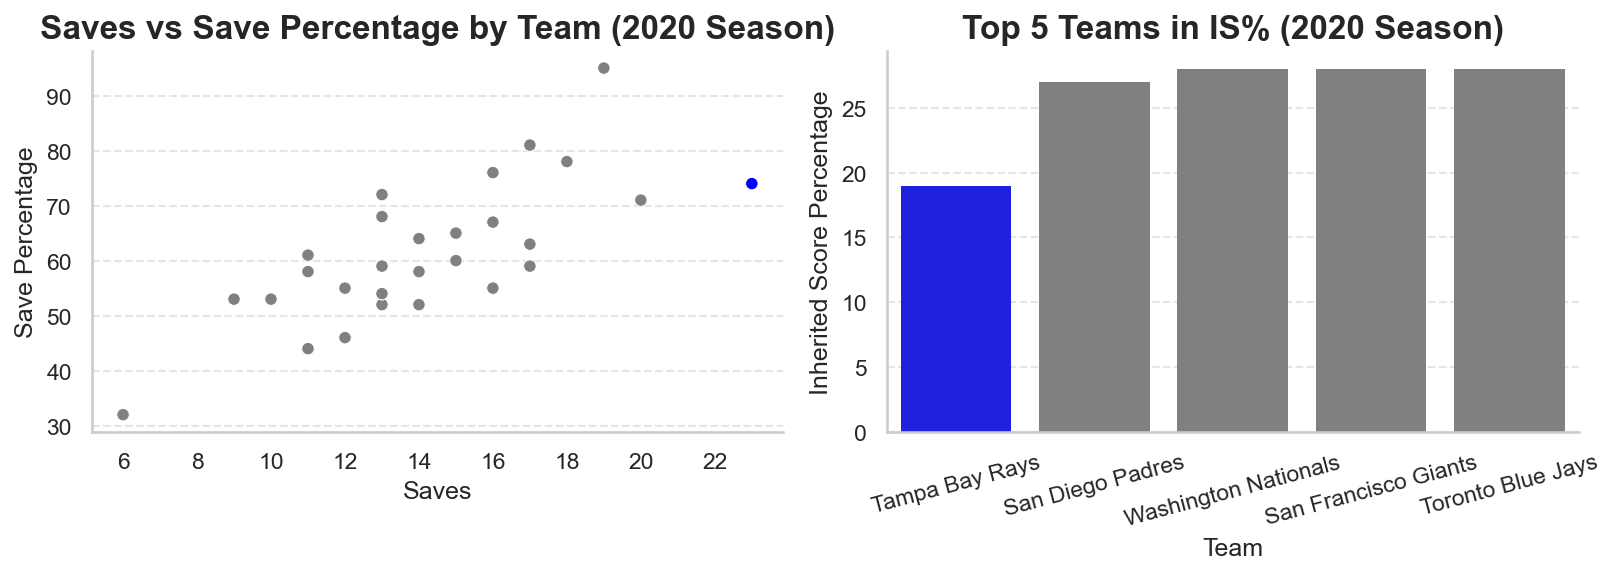

In [19]:
team_2020_reliefpitchstats = pd.read_csv("team_2020_reliefpitchstats.csv")
team_2020_reliefpitchstats["Rays"] = team_2020_reliefpitchstats.apply(lambda x: True if x.Tm == "Tampa Bay Rays" else False, axis=1)
top_5_ISpercent = team_2020_reliefpitchstats.sort_values("IS%", ascending=True).head()
top_5_ISpercent["Rays"] = top_5_ISpercent.apply(lambda x: True if x.Tm == "Tampa Bay Rays" else False, axis= 1)

plt.figure(figsize=(11,4))

plt.subplot(1, 2, 1)
y = sns.scatterplot(data=team_2020_reliefpitchstats, x="SV", y="SV%", hue="Rays", palette= {True:"blue", False:"grey"}, legend=False)
y.xaxis.set_major_locator(MultipleLocator(2))
plt.xlabel("Saves")
plt.ylabel("Save Percentage")
plt.title("Saves vs Save Percentage by Team (2020 Season)")

plt.subplot(1, 2, 2)
sns.barplot(data=top_5_ISpercent, x="Tm", y="IS%", hue="Rays", palette= {True: "blue", False: "grey"}, legend=False)
plt.xlabel("Team")
plt.ylabel("Inherited Score Percentage")
plt.title("Top 5 Teams in IS% (2020 Season)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

This bullpen was led by 3 little-known relievers at the time - Nick Anderson, Diego Castillo, and John Curtiss. Before the 2020 season none of these relievers had been in the majors for 5 years, had a combined 0 all-star appearances, and had a combined 9 saves. These players were all under the age of 30, being a relatively young group of pitchers. During the season the 3 of them combined for 12 saves, were the top 3 pitchers in ERA+ on the Rays, and all had an ERA under 2.

In [20]:
print(rays_2020_pitchstats.sort_values("ERA+", ascending=False).head(3)[["ERA", "SV", "ERA+"]])

                 ERA  SV   ERA+
player                         
Nick Anderson   0.55   6  756.0
Diego Castillo  1.66   4  249.0
John Curtiss    1.80   2  230.0


### Reliever of the Year

The Mariano Rivera Award is presented to the best reliever in the American League every year. The pitcher who won this award in 2020 was Liam Hendriks, the closer for the Oakland Athletics. He won this award posting 14 saves as well as career lows in ERA and WHIP (1.78, 0.671.) 

You may be asking, what does this have to do with the Rays? Through the combined effort from bullpen arms, they basically had him on their roster for $635,000. The Rays' big three relievers (Anderson, Castillo, Curtiss) in signficantly more innings posted a higher ERA+, similar save numbers to Hendriks, as well as boasting a lower total ERA. They also combined only blew 1 more save than Hendriks.

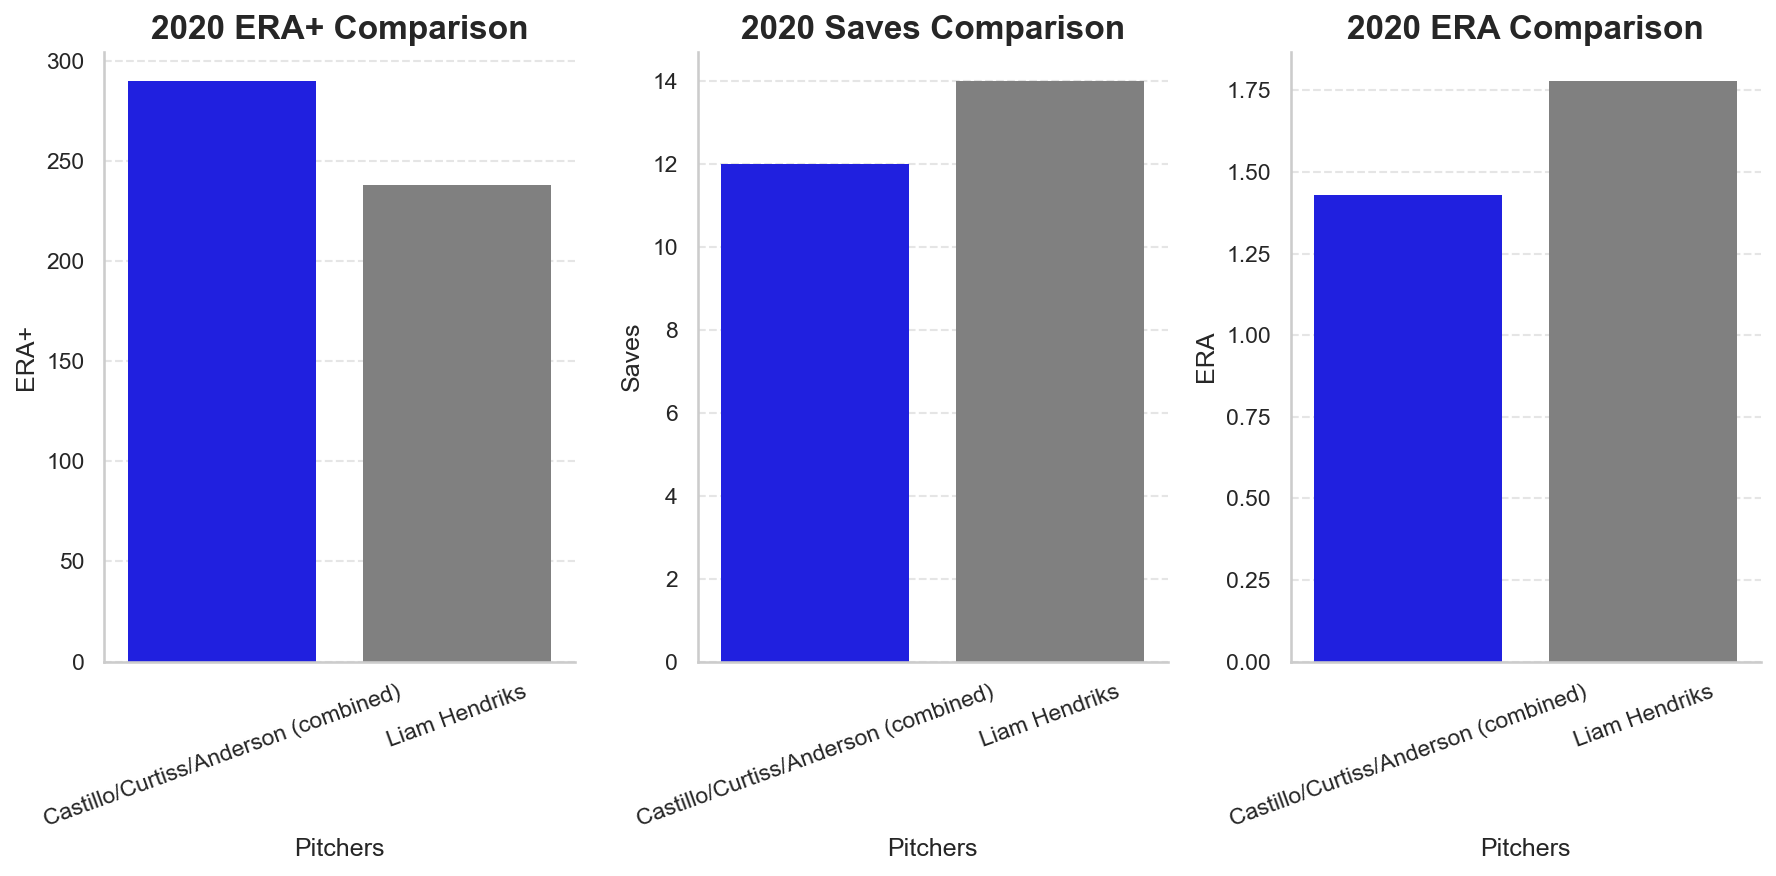

In [21]:
closer_comp = pd.read_csv("closer_comp.csv")
closer_comp["Rays"] = closer_comp.apply(lambda x: True if x.player == "Castillo/Curtiss/Anderson (combined)" else False, axis=1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.barplot(data=closer_comp, x="player", y="ERA+", hue="Rays", palette= {True: "blue", False: "grey"}, legend=False)
plt.xlabel("Pitchers")
plt.ylabel("ERA+")
plt.title("2020 ERA+ Comparison")
plt.xticks(rotation=20)

plt.subplot(1, 3, 2)
sns.barplot(data=closer_comp, x="player", y="SV", hue="Rays", palette= {True: "blue", False: "grey"}, legend=False)
plt.xlabel("Pitchers")
plt.ylabel("Saves")
plt.title("2020 Saves Comparison")
plt.xticks(rotation=20)

plt.subplot(1, 3, 3)
sns.barplot(data=closer_comp, x="player", y="ERA", hue="Rays", palette= {True: "blue", False: "grey"}, legend=False)
plt.xlabel("Pitchers")
plt.ylabel("ERA")
plt.title("2020 ERA Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

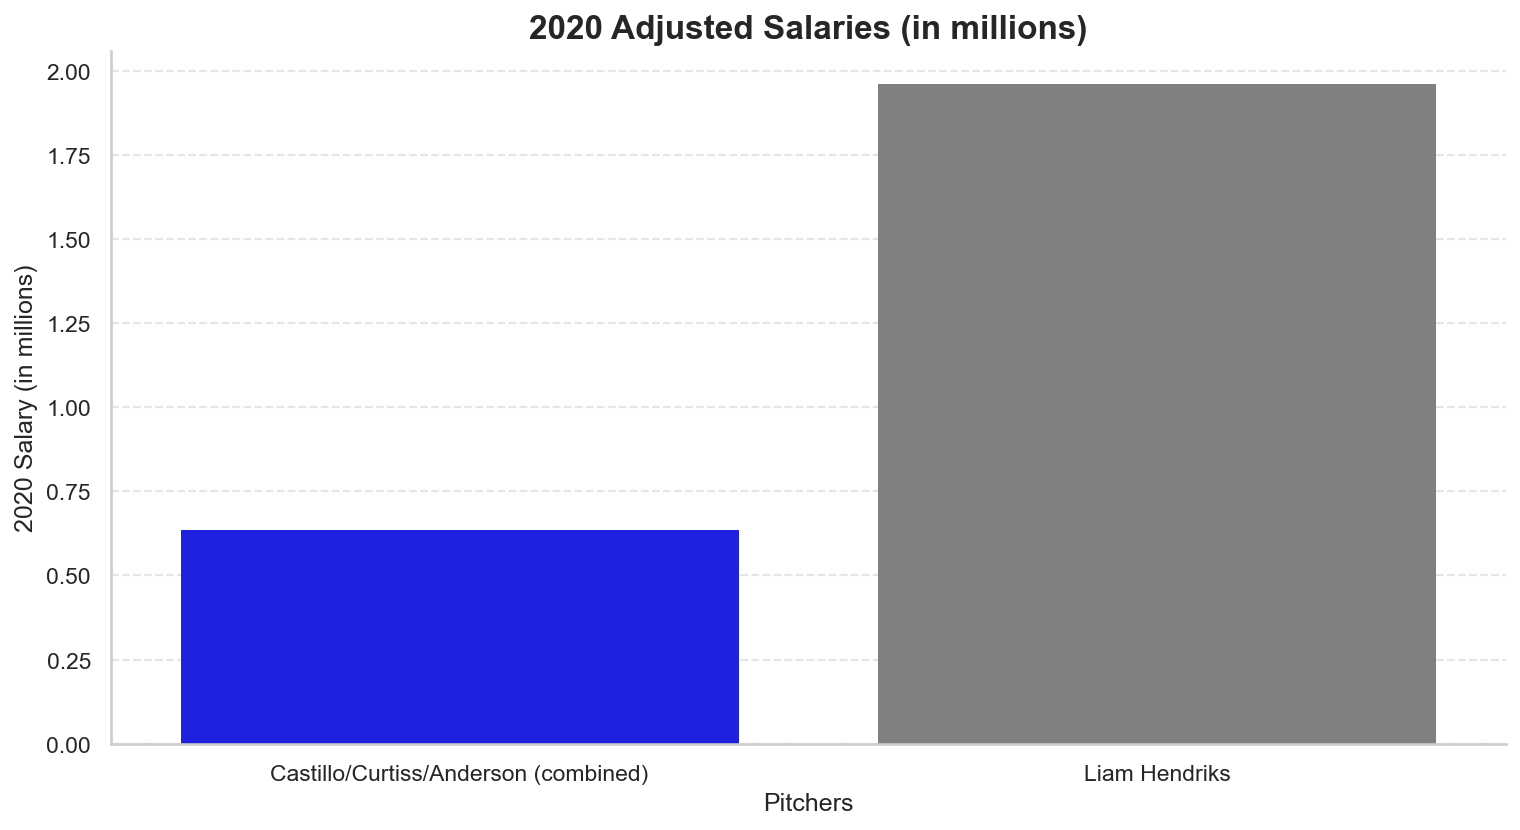

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(data=closer_comp, x="player", y="Salary", hue="Rays", palette= {True: "blue", False: "grey"}, legend=None)
plt.xlabel("Pitchers")
plt.ylabel("2020 Salary (in millions)")
plt.title("2020 Adjusted Salaries (in millions)")
plt.show()


Another Moneyball-esque concept, using multiple players to replicate production from a star is perfectly executed right here. The stats between the combined Rays crew were similar to the AL reliever of the year, in significantly more innings. The most impressive part about this move though was the amount of money it saved the organization. Liam Hendriks earned almost $2 million during the 2020 seasons. The Rays big 3 cost Tampa Bay right around a third of the cost for Hendriks. This may be one of if not the most impressive part of this team. Getting reliever of the year production for a massive discount is a top tier front office move.

# Summary

This project has been proof that small market teams can keep up with the heavy hitters, through managing their finances well and being efficient in their roster moves. The Tampa Bay Rays were able to boast a top tier starting rotation, as well as an elite bullpen all while managing one of the lowest budgets in the league. 

Through fantastic scouting and player development, the Rays turned a player who once lacked elite "stuff" and big league control into a Cy Young winning pitcher. Through trade, in an absolute stroke of genius, the front office sent an aging all-star away for a young, projectable prospect in what turned out to be one of the most lopsided trades of all time. The Rays used an unorthodox delivery to their advantage, getting elite level production out of a pre-arbitration arm. Lastly, they used multiple relievers in a "Moneyball-esque" way to have the output of a "lockdown closer" without spending "lockdown closer" money. 

Overall the Rays' front office used the entire book and through elite young pre-arbitration talent, low budget signings, and world-class player development they showed that with good market efficiency, the small-market teams can still compete.